# Coursework 1

This notebook is intended to be used as a starting point for your experiments. The instructions can be found in the MLP2025_26_CW1_Spec.pdf (see Learn,  Assignment Submission, Coursework 1). The methods provided here are just helper functions. If you want more complex graphs such as side by side comparisons of different experiments you should learn more about matplotlib and implement them. Before each experiment remember to re-initialize neural network weights and reset the data providers so you get a properly initialized experiment. For each experiment try to keep most hyperparameters the same except the one under investigation so you can understand what the effects of each are.

## Training Boilerplate

Use the below code as a boilerplate to start your experiments. You can add more cells or change the code as you see fit.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import logging
import sys 
sys.path.append(r"C:\Users\User\mlpractical")

from mlp.data_providers import MNISTDataProvider, EMNISTDataProvider
from mlp.layers import AffineLayer, SoftmaxLayer, SigmoidLayer, ReluLayer, CustomActivationLayer
from mlp.errors import CrossEntropySoftmaxError
from mlp.models import MultipleLayerModel
from mlp.initialisers import ConstantInit, GlorotUniformInit
from mlp.learning_rules import AdamLearningRule
from mlp.optimisers import Optimiser

In [3]:
%matplotlib inline
plt.style.use('ggplot')

def train_model_and_plot_stats(
        model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True):
    
    # As well as monitoring the error over training also monitor classification
    # accuracy i.e. proportion of most-probable predicted classes being equal to targets
    data_monitors={'acc': lambda y, t: (y.argmax(-1) == t.argmax(-1)).mean()}

    # Use the created objects to initialise a new Optimiser instance.
    optimiser = Optimiser(
        model, error, learning_rule, train_data, valid_data, data_monitors, notebook=notebook)

    # Run the optimiser for num_epochs epochs (full passes through the training set)
    # printing statistics every epoch.
    stats, keys, run_time = optimiser.train(num_epochs=num_epochs, stats_interval=stats_interval)

    # Plot the change in the validation and training set error over training.
    fig_1 = plt.figure(figsize=(8, 4))
    ax_1 = fig_1.add_subplot(111)
    for k in ['error(train)', 'error(valid)']:
        ax_1.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_1.legend(loc=0)
    ax_1.set_xlabel('Epoch number')
    ax_1.set_ylabel('Error')

    # Plot the change in the validation and training set accuracy over training.
    fig_2 = plt.figure(figsize=(8, 4))
    ax_2 = fig_2.add_subplot(111)
    for k in ['acc(train)', 'acc(valid)']:
        ax_2.plot(np.arange(1, stats.shape[0]) * stats_interval, 
                  stats[1:, keys[k]], label=k)
    ax_2.legend(loc=0)
    ax_2.set_xlabel('Epoch number')
    ax_2.set_xlabel('Accuracy')

    grad_plot, grad_ax = optimiser.plot_grad_flow()

    return stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax

In [4]:
# The below code will set up the data providers, random number
# generator and logger objects needed for training runs. As
# loading the data from file take a little while you generally
# will probably not want to reload the data providers on
# every training run. If you wish to reset their state you
# should instead use the .reset() method of the data providers.

# Seed a random number generator
seed = 111020
rng = np.random.RandomState(seed)
batch_size = 100
# Set up a logger object to print info about the training run to stdout
logger = logging.getLogger()
logger.setLevel(logging.INFO)
logger.handlers = [logging.StreamHandler()]

# Create data provider objects for the MNIST data set
train_data = EMNISTDataProvider('train', batch_size=batch_size, rng=rng)
valid_data = EMNISTDataProvider('valid', batch_size=batch_size, rng=rng)

KeysView(NpzFile 'C:/Users/User/mlpractical/data\\emnist-train.npz' with keys: inputs, targets)
KeysView(NpzFile 'C:/Users/User/mlpractical/data\\emnist-valid.npz' with keys: inputs, targets)


Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 4.0s to complete
    error(train)=7.72e-01, acc(train)=7.60e-01, error(valid)=7.87e-01, acc(valid)=7.58e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Epoch 98: 3.0s to complete
    error(train)=8.75e-02, acc(train)=9.64e-01, error(valid)=1.52e+00, acc(valid)=8.16e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 4.1s to complete
    error(train)=1.11e-01, acc(train)=9.56e-01, error(valid)=1.59e+00, acc(valid)=8.15e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 3.7s to complete
    error(train)=9.95e-02, acc(train)=9.60e-01, error(valid)=1.56e+00, acc(valid)=8.17e-01


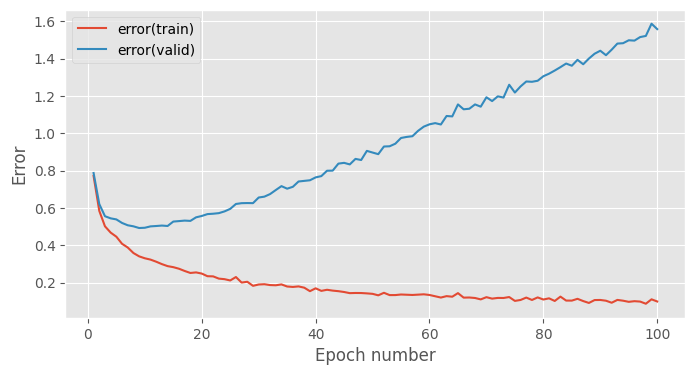

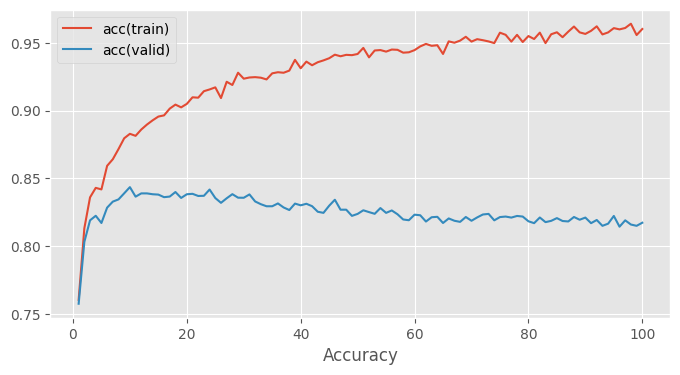

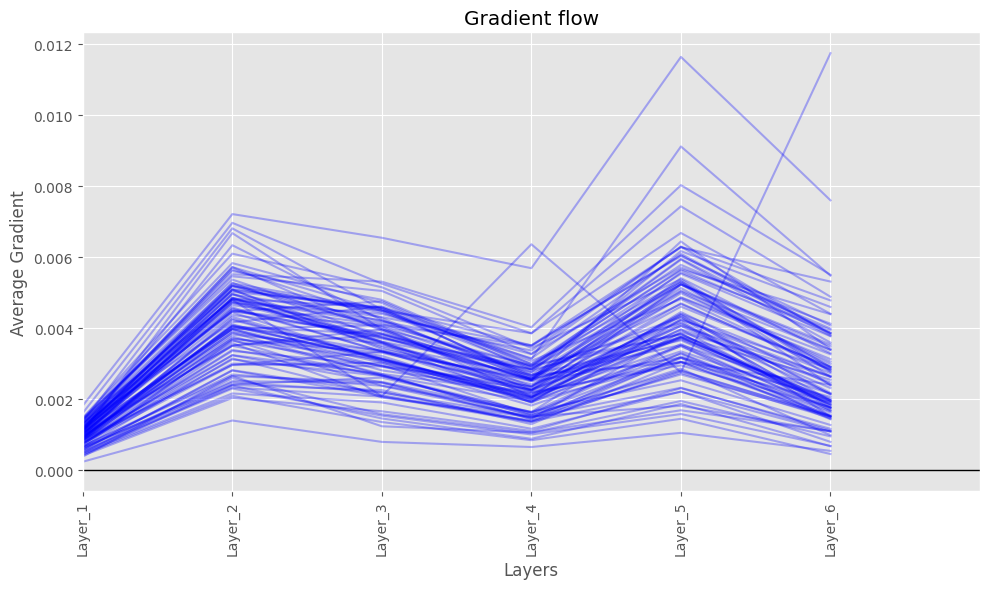

In [5]:
# The model set up code below is provided as a starting point.
# You will probably want to add further code cells for the
# different experiments you run.

%pip install tqdm

# Setup hyperparameters
learning_rate = 0.001
num_epochs = 100
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with TWO hidden layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), # first hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # second hidden layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

## HIDDEN UNITS

In [7]:
import json

In [8]:
results_file_w = 'table_1_results_individual.json'
HEADERS_W = ["# Hidden Units", "Val. Acc. (%)", "Train Error", "Val. Error"]
num_hidden_layers = 2

# INITIALIZE RESULTS FILE
with open(results_file_w, 'w') as f:
    json.dump({"headers": HEADERS_W, "data": []}, f)

print(f"[SETUP] Initializing results file for Width Analysis: '{results_file_w}'.")

# Initialize common objects (assuming num_hidden_layers is 2)
weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)
error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)

[SETUP] Initializing results file for Width Analysis: 'table_1_results_individual.json'.



--- Starting Experiment: Width 32 Hidden Units ---


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.2s to complete
    error(train)=1.17e+00, acc(train)=6.65e-01, error(valid)=1.18e+00, acc(valid)=6.60e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 1.3s to complete
    error(train)=4.85e-01, acc(train)=8.35e-01, error(valid)=6.64e-01, acc(valid)=7.95e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 1.3s to complete
    error(train)=4.81e-01, acc(train)=8.40e-01, error(valid)=6.61e-01, acc(valid)=8.02e-01



[SUCCESS] Width 32 Experiment completed.
  Val Acc: 80.17%, Train Error: 0.4808, Val Error: 0.6610


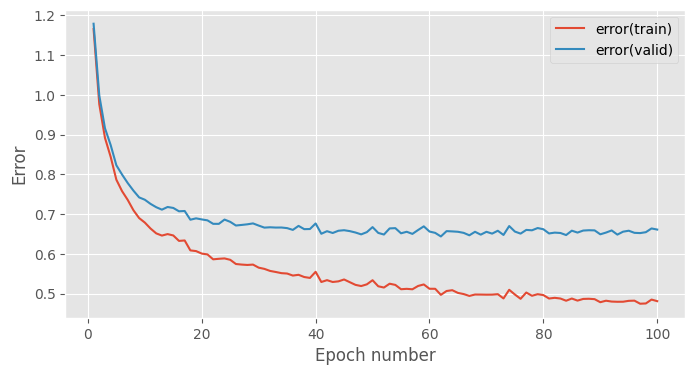

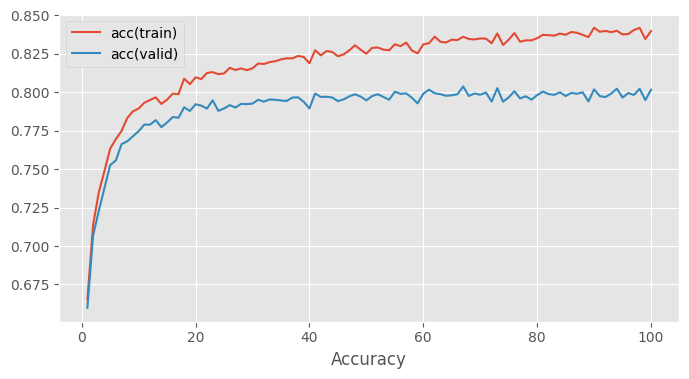

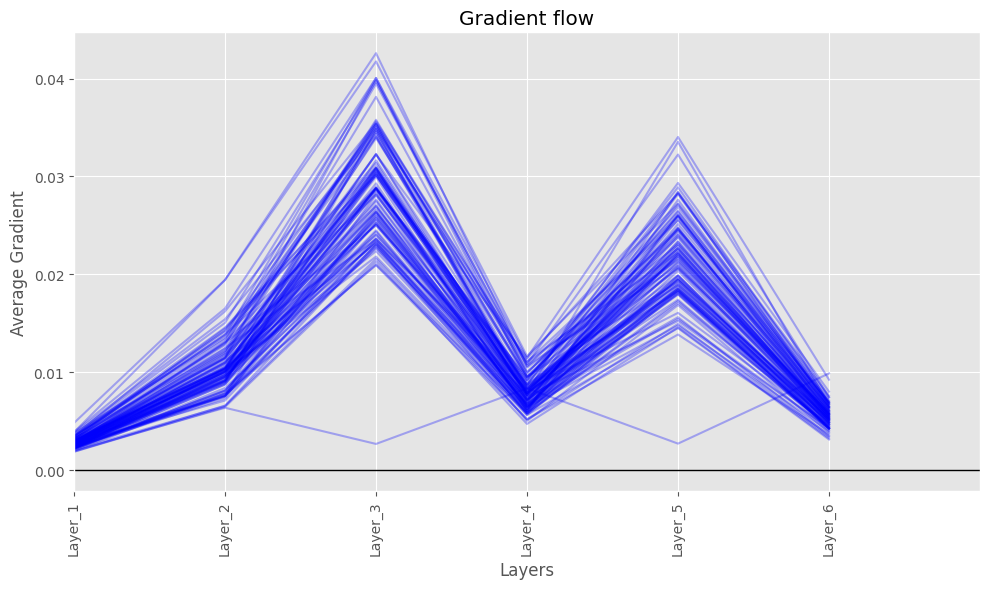

In [9]:
hidden_dim = 32

print(f"\n--- Starting Experiment: Width {hidden_dim} Hidden Units ---")

model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

global stats_w32
stats_w32, keys, run_time, *rest = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

final_stats = stats_w32[-1]
final_val_acc = final_stats[keys['acc(valid)']] * 100 
final_train_err = final_stats[keys['error(train)']]
final_val_err = final_stats[keys['error(valid)']]

# LOAD, APPEND, AND SAVE
with open(results_file_w, 'r') as f:
    results = json.load(f)

results['data'].append([hidden_dim, f"{final_val_acc:.2f}", f"{final_train_err:.4f}", f"{final_val_err:.4f}"])

with open(results_file_w, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n[SUCCESS] Width {hidden_dim} Experiment completed.")
print(f"  Val Acc: {final_val_acc:.2f}%, Train Error: {final_train_err:.4f}, Val Error: {final_val_err:.4f}")


--- Starting Experiment: Width 64 Hidden Units ---


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 1.8s to complete
    error(train)=9.01e-01, acc(train)=7.34e-01, error(valid)=9.24e-01, acc(valid)=7.23e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.4s to complete
    error(train)=2.59e-01, acc(train)=9.01e-01, error(valid)=7.55e-01, acc(valid)=8.10e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.3s to complete
    error(train)=2.57e-01, acc(train)=9.03e-01, error(valid)=7.63e-01, acc(valid)=8.14e-01



[SUCCESS] Width 64 Experiment completed.
  Val Acc: 81.37%, Train Error: 0.2567, Val Error: 0.7630


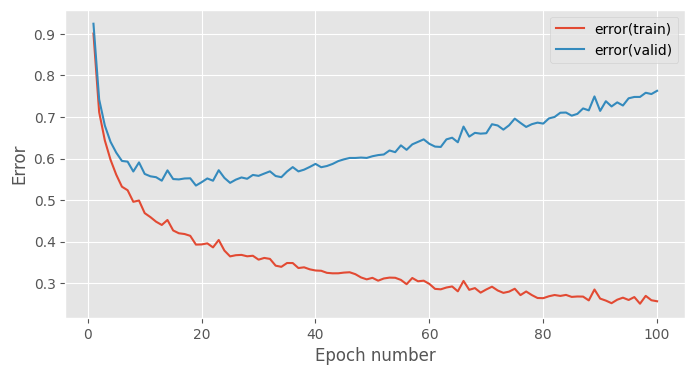

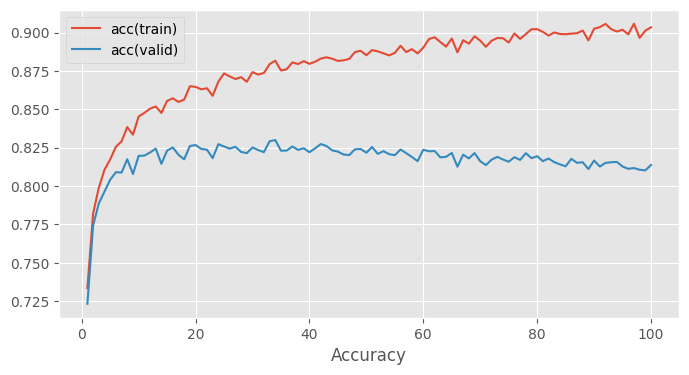

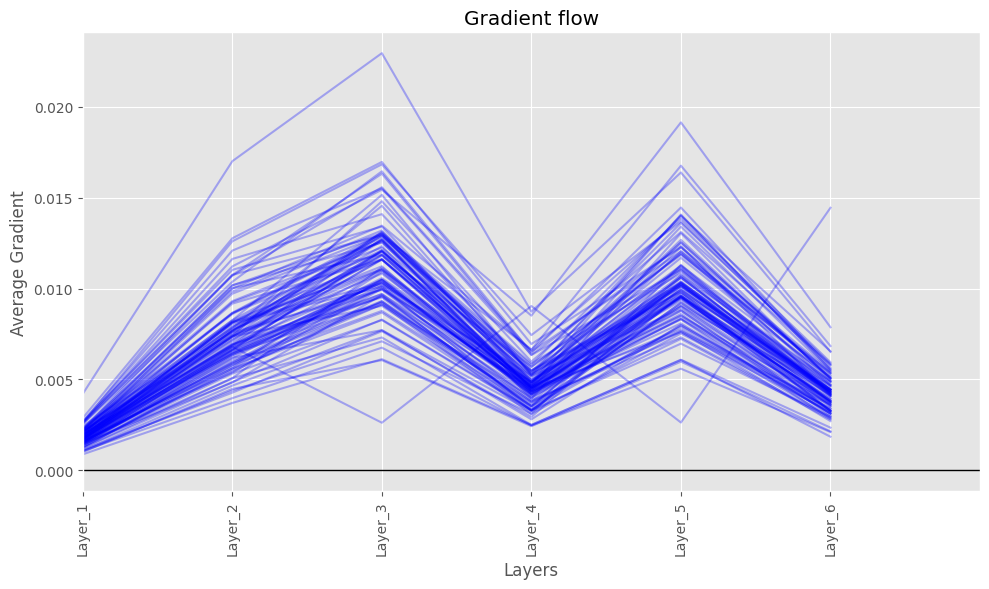

In [10]:
hidden_dim = 64

print(f"\n--- Starting Experiment: Width {hidden_dim} Hidden Units ---")

model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

global stats_w64
stats_w64, keys, run_time, *rest = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

final_stats = stats_w64[-1]
final_val_acc = final_stats[keys['acc(valid)']] * 100 
final_train_err = final_stats[keys['error(train)']]
final_val_err = final_stats[keys['error(valid)']]

# LOAD, APPEND, AND SAVE
with open(results_file_w, 'r') as f:
    results = json.load(f)

results['data'].append([hidden_dim, f"{final_val_acc:.2f}", f"{final_train_err:.4f}", f"{final_val_err:.4f}"])

with open(results_file_w, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n[SUCCESS] Width {hidden_dim} Experiment completed.")
print(f"  Val Acc: {final_val_acc:.2f}%, Train Error: {final_train_err:.4f}, Val Error: {final_val_err:.4f}")


--- Starting Experiment: Width 128 Hidden Units ---


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.6s to complete
    error(train)=7.51e-01, acc(train)=7.69e-01, error(valid)=7.79e-01, acc(valid)=7.60e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 3.3s to complete
    error(train)=9.27e-02, acc(train)=9.62e-01, error(valid)=1.58e+00, acc(valid)=8.23e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 3.3s to complete
    error(train)=1.02e-01, acc(train)=9.59e-01, error(valid)=1.59e+00, acc(valid)=8.18e-01



[SUCCESS] Width 128 Experiment completed.
  Val Acc: 81.76%, Train Error: 0.1023, Val Error: 1.5897
Data saved. Proceed to the next cell when ready.


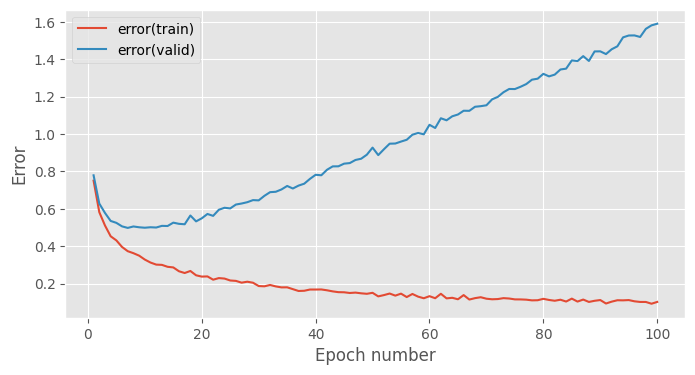

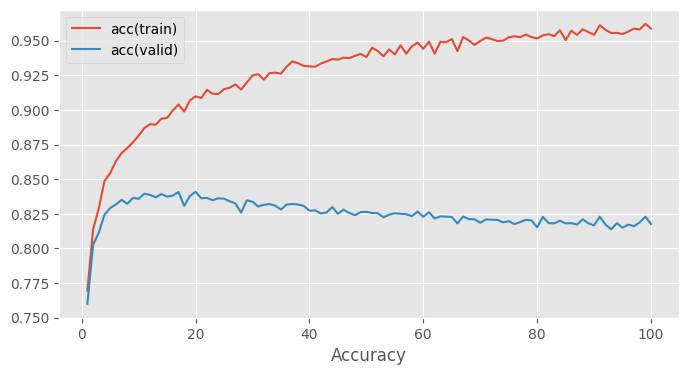

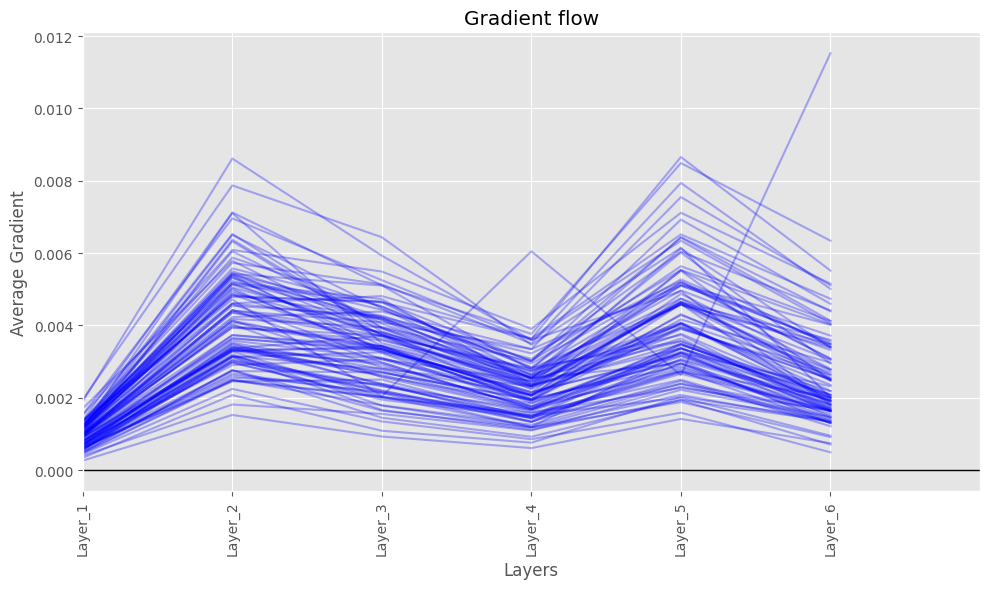

In [11]:
hidden_dim = 128

print(f"\n--- Starting Experiment: Width {hidden_dim} Hidden Units ---")
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

global stats_w128
stats_w128, keys, run_time, *rest = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

final_stats = stats_w128[-1]
final_val_acc = final_stats[keys['acc(valid)']] * 100 
final_train_err = final_stats[keys['error(train)']]
final_val_err = final_stats[keys['error(valid)']]

# LOAD, APPEND, AND SAVE
with open(results_file_w, 'r') as f:
    results = json.load(f)

results['data'].append([hidden_dim, f"{final_val_acc:.2f}", f"{final_train_err:.4f}", f"{final_val_err:.4f}"])

with open(results_file_w, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n[SUCCESS] Width {hidden_dim} Experiment completed.")
print(f"  Val Acc: {final_val_acc:.2f}%, Train Error: {final_train_err:.4f}, Val Error: {final_val_err:.4f}")
print("Data saved. Proceed to the next cell when ready.")

In [12]:
import json

def display_table(headers, data):
    data_str = [[str(r[0])] + r[1:] for r in data]
    col_widths = [max(len(h), max(len(d[i]) for d in data_str) if data_str else 0) + 4
                  for i, h in enumerate(headers)]
    
    separator_line = "+" + "+".join(["-" * (w - 2) for w in col_widths]) + "+"
    total_width = len(separator_line)

    print("\n" + "="*total_width)
    print(f"| {'TABLE 1: VARYING NETWORK WIDTHS':^{total_width-2}} |")
    print("="*total_width)
    
    header_line = "|"
    for i, header in enumerate(headers):
        header_line += f" {header:^{col_widths[i]-2}} |"
    print(header_line)
    print(separator_line)

    for row in data_str:
        row_line = "|"
        for i, item in enumerate(row):
             row_line += f" {item:^{col_widths[i]-2}} |"
        print(row_line)

    print(separator_line)
    print("="*total_width + "\n")


# LOAD DATA AND DISPLAY
results_file = 'table_1_results_individual.json'

try:
    with open(results_file, 'r') as f:
        results = json.load(f)
    
    # Sort the data by the number of hidden units (first column) to ensure correct order
    sortable_data = [[int(row[0])] + row[1:] for row in results['data']]
    sortable_data.sort(key=lambda x: x[0])
    
    display_table(results['headers'], sortable_data)

except FileNotFoundError:
    print(f"[ERROR] File '{results_file}' not found. Please run all training cells (2, 3, and 4) first.")
except Exception as e:
    print(f"[ERROR] Could not load or display results: {e}")



|               TABLE 1: VARYING NETWORK WIDTHS               |
|  # Hidden Units  |  Val. Acc. (%)  |  Train Error  |  Val. Error  |
+----------------+---------------+-------------+------------+
|        32        |      80.17      |    0.4808     |    0.6610    |
|        64        |      81.37      |    0.2567     |    0.7630    |
|       128        |      81.76      |    0.1023     |    1.5897    |
+----------------+---------------+-------------+------------+



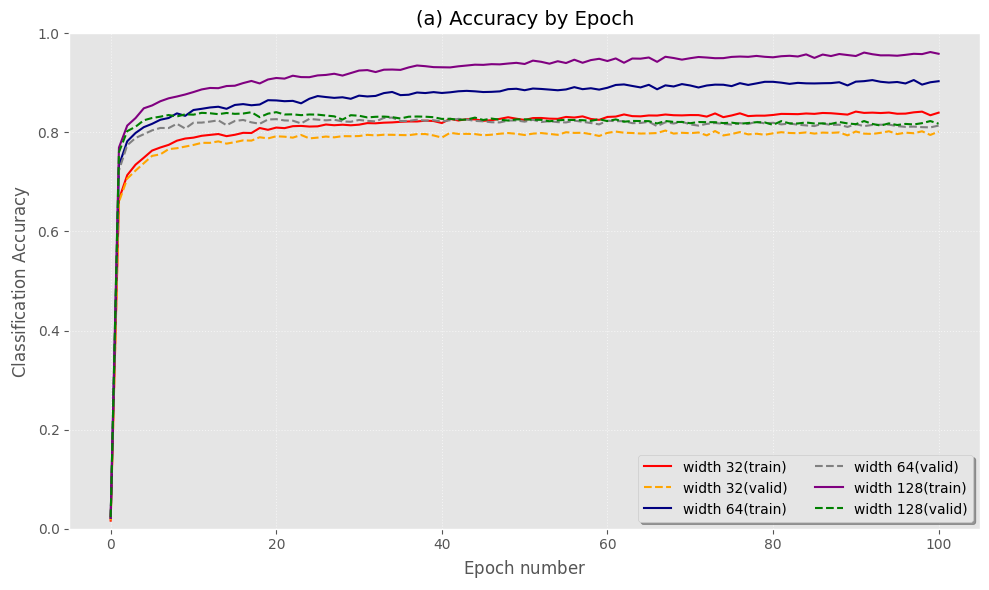

In [13]:
import matplotlib.pyplot as plt
import numpy as np

WIDTH_CURVE_STYLES = {
    # Train curves (Solid lines)
    32:  {'color': 'red', 'linestyle': '-', 'label': 'width 32(train)'},  
    64:  {'color': 'navy', 'linestyle': '-', 'label': 'width 64(train)'},  
    128: {'color': 'purple', 'linestyle': '-', 'label': 'width 128(train)'},
    
    # Validation curves (Dashed lines)
    '32_valid': {'color': 'orange', 'linestyle': '--', 'label': 'width 32(valid)'}, 
    '64_valid': {'color': 'grey', 'linestyle': '--', 'label': 'width 64(valid)'}, 
    '128_valid': {'color': 'green', 'linestyle': '--', 'label': 'width 128(valid)'} 
}
widths = [32, 64, 128]

try:
    all_stats_width = {32: stats_w32, 64: stats_w64, 128: stats_w128}
    epochs = np.arange(0, num_epochs + stats_interval, stats_interval) 
except NameError as e:
    print(f"[ERROR] Variable missing: {e}. Please ensure all width experiment cells ran.")
    raise

# Plot Generation for ACCURACY
fig, ax = plt.subplots(1, 1, figsize=(10, 6)) # Single subplot

all_handles = []
all_labels = []

for width in widths:
    stats = all_stats_width[width]
    
    train_acc = [s[keys['acc(train)']] for s in stats]
    valid_acc = [s[keys['acc(valid)']] for s in stats]
    
    # Plot Train (Solid)
    h_train, = ax.plot(epochs, train_acc, **WIDTH_CURVE_STYLES[width])
    # Plot Validation (Dashed)
    h_valid, = ax.plot(epochs, valid_acc, **WIDTH_CURVE_STYLES[f'{width}_valid'])
    
    all_handles.extend([h_train, h_valid])
    all_labels.extend([WIDTH_CURVE_STYLES[width]['label'], WIDTH_CURVE_STYLES[f'{width}_valid']['label']])

# Formatting
ax.set_title(r'(a) Accuracy by Epoch', fontsize=14)
ax.set_xlabel(r'$\mathrm{Epoch\ number}$', fontsize=12)
ax.set_ylabel(r'$\mathrm{Classification\ Accuracy}$', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_ylim(0, 1.0) 

ax.legend(all_handles, all_labels, 
          loc='lower right', 
          ncol=2, 
          fontsize=10,
          frameon=True, 
          fancybox=True, 
          shadow=True) 

# SAVE FIGURE TO PDF
fig.tight_layout() 
save_filename = 'emnist_width_accuracy_curves.png'
fig.savefig(save_filename)
plt.show()

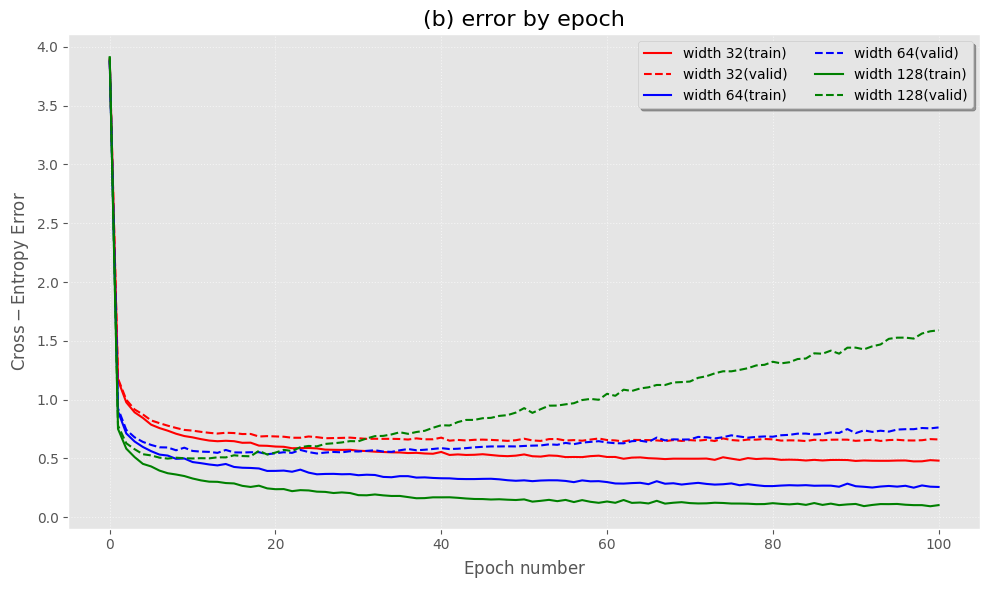

In [15]:
WIDTH_CURVE_STYLES = {
    32:  {'color': 'red', 'linestyle': '-', 'label': 'width 32(train)'},  
    64:  {'color': 'blue', 'linestyle': '-', 'label': 'width 64(train)'},  
    128: {'color': 'green', 'linestyle': '-', 'label': 'width 128(train)'},
    '32_valid': {'color': 'red', 'linestyle': '--', 'label': 'width 32(valid)'}, 
    '64_valid': {'color': 'blue', 'linestyle': '--', 'label': 'width 64(valid)'}, 
    '128_valid': {'color': 'green', 'linestyle': '--', 'label': 'width 128(valid)'} 
}
widths = [32, 64, 128]

try:
    all_stats_width = {32: stats_w32, 64: stats_w64, 128: stats_w128}
    epochs = np.arange(0, num_epochs + stats_interval, stats_interval) 
except NameError as e:
    print(f"[ERROR] Variable missing: {e}. Please ensure all width experiment cells ran.")
    raise

# Plot Generation for ERROR (Width)
fig, ax = plt.subplots(1, 1, figsize=(10, 6)) # Single subplot

all_handles = []
all_labels = []

for width in widths:
    stats = all_stats_width[width]
    
    train_error = [s[keys['error(train)']] for s in stats]
    valid_error = [s[keys['error(valid)']] for s in stats]
    
    # Plot Train (Solid)
    h_train, = ax.plot(epochs, train_error, **WIDTH_CURVE_STYLES[width])
    # Plot Validation (Dashed)
    h_valid, = ax.plot(epochs, valid_error, **WIDTH_CURVE_STYLES[f'{width}_valid'])
    
    all_handles.extend([h_train, h_valid])
    all_labels.extend([WIDTH_CURVE_STYLES[width]['label'], WIDTH_CURVE_STYLES[f'{width}_valid']['label']])

# Formatting
ax.set_title(r'(b) error by epoch', fontsize=16) 
ax.set_xlabel(r'$\mathrm{Epoch\ number}$', fontsize=12)
ax.set_ylabel(r'$\mathrm{Cross-Entropy\ Error}$', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)

ax.legend(all_handles, all_labels, 
          loc='upper right', 
          ncol=2, 
          fontsize=10,
          frameon=True, 
          fancybox=True, 
          shadow=True) 

# SAVE FIGURE TO PDF
fig.tight_layout()
save_filename = 'emnist_width_error_curves.png'
fig.savefig(save_filename)
plt.show()

## HIDDEN LAYER

In [16]:
learning_rate = 0.001 
num_epochs = 100
stats_interval = 1
input_dim, output_dim = 784, 47 
hidden_dim = 128 

# File names
results_file_2 = 'table_2_results_depth.json'
HEADERS_2 = ["# Hidden Layers", "Val. Acc. (%)", "Train Error", "Val. Error"]

# --- INITIALIZE RESULTS FILE ---
# Clears old data and sets up the file for incremental saving
with open(results_file_2, 'w') as f:
    json.dump({"headers": HEADERS_2, "data": []}, f)

print(f"[SETUP] Starting Depth Analysis. Fixed Hidden Units: {hidden_dim}.")
print(f"Results will be saved to '{results_file_2}'. Full stats will be saved to files.")

# Initialize common objects
weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)
error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)

[SETUP] Starting Depth Analysis. Fixed Hidden Units: 128.
Results will be saved to 'table_2_results_depth.json'. Full stats will be saved to files.



--- Starting Experiment: 1 Hidden Layer(s) ---


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.8s to complete
    error(train)=9.35e-01, acc(train)=7.30e-01, error(valid)=9.58e-01, acc(valid)=7.23e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 2.4s to complete
    error(train)=1.57e-01, acc(train)=9.39e-01, error(valid)=9.59e-01, acc(valid)=8.07e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 2.7s to complete
    error(train)=1.60e-01, acc(train)=9.37e-01, error(valid)=9.80e-01, acc(valid)=8.04e-01



[SUCCESS] Depth 1 Experiment completed.
  Val Acc: 80.38%, Train Error: 0.1600, Val Error: 0.9805
Data saved. Proceed to the next cell when ready.


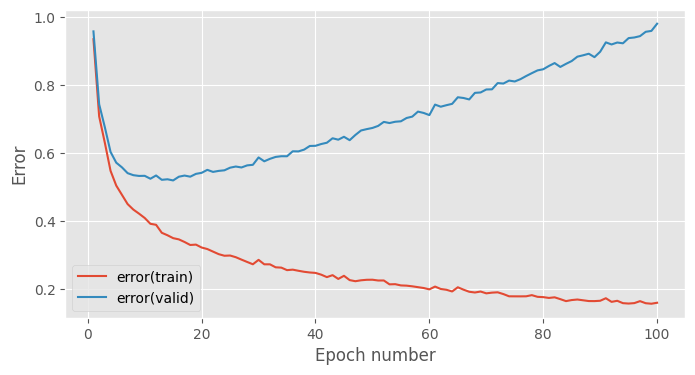

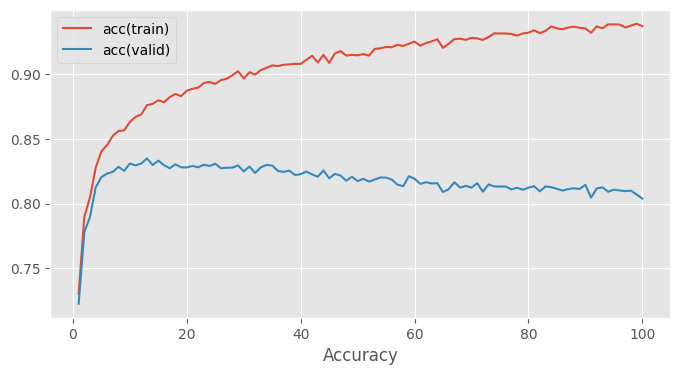

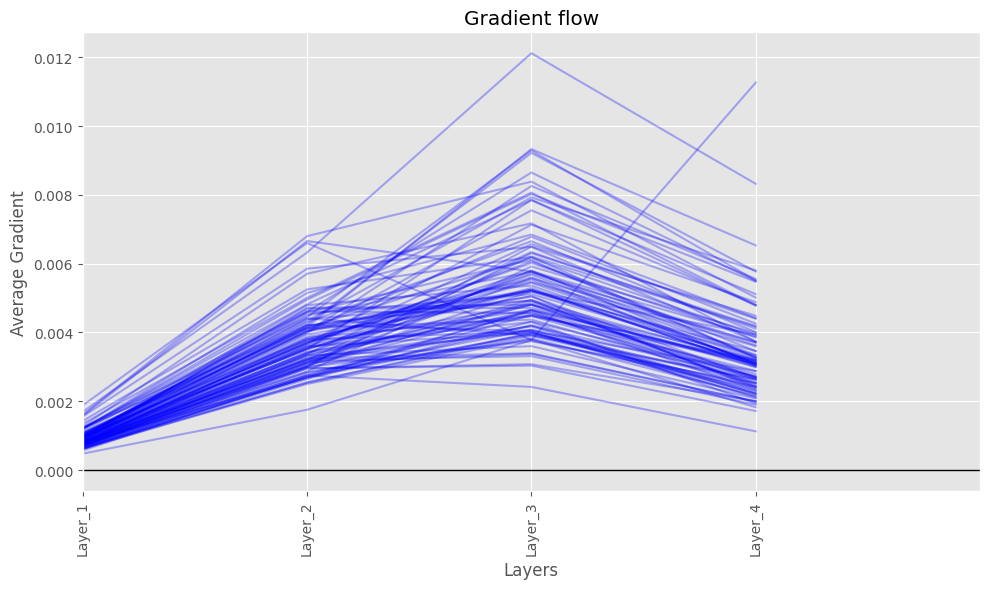

In [17]:
# --- Configuration for this specific run ---
num_hidden_layers = 1

# --- MODEL SETUP ---
print(f"\n--- Starting Experiment: {num_hidden_layers} Hidden Layer(s) ---")
weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# MODEL DEFINITION: 1 Hidden Layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Run the training
# NOTE: stats_1 is a GLOBAL variable used by the plotting cell later.
stats_1, keys, run_time, *rest = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

# --- DATA EXTRACTION & SAVING ---
final_stats = stats_1[-1]
final_val_acc = final_stats[keys['acc(valid)']] * 100 
final_train_err = final_stats[keys['error(train)']]
final_val_err = final_stats[keys['error(valid)']]

# --- LOAD, APPEND, AND SAVE ---
with open(results_file_2, 'r') as f:
    results = json.load(f)

# Store results
results['data'].append([
    num_hidden_layers,
    f"{final_val_acc:.2f}",
    f"{final_train_err:.4f}",
    f"{final_val_err:.4f}"
])

with open(results_file_2, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n[SUCCESS] Depth {num_hidden_layers} Experiment completed.")
print(f"  Val Acc: {final_val_acc:.2f}%, Train Error: {final_train_err:.4f}, Val Error: {final_val_err:.4f}")
print("Data saved. Proceed to the next cell when ready.")


--- Starting Experiment: 2 Hidden Layer(s) ---


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.1s to complete
    error(train)=7.53e-01, acc(train)=7.68e-01, error(valid)=7.74e-01, acc(valid)=7.62e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 3.3s to complete
    error(train)=1.08e-01, acc(train)=9.55e-01, error(valid)=1.55e+00, acc(valid)=8.20e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 3.7s to complete
    error(train)=1.14e-01, acc(train)=9.54e-01, error(valid)=1.55e+00, acc(valid)=8.15e-01



[SUCCESS] Depth 2 Experiment completed.
  Val Acc: 81.48%, Train Error: 0.1143, Val Error: 1.5516
Data saved. Proceed to the next cell when ready.


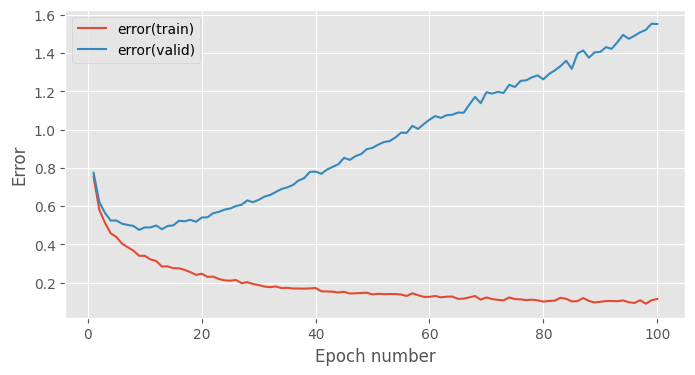

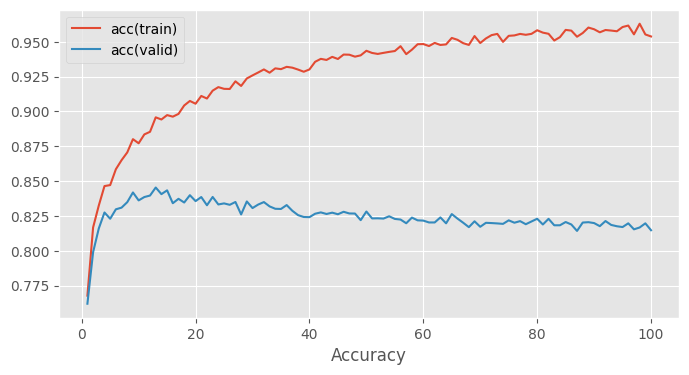

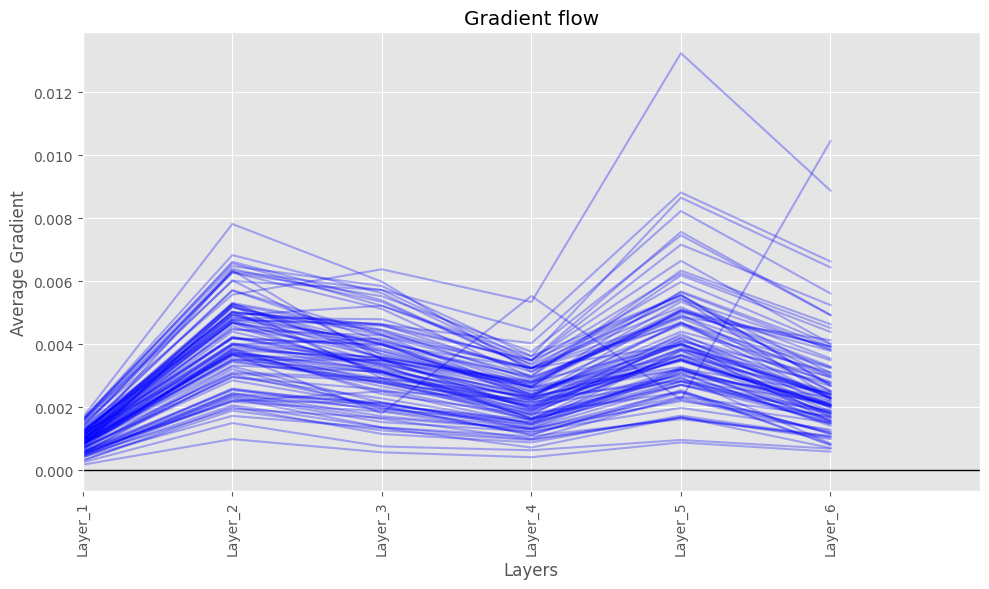

In [19]:
# --- Configuration for this specific run ---
num_hidden_layers = 2

# --- MODEL SETUP ---
print(f"\n--- Starting Experiment: {num_hidden_layers} Hidden Layer(s) ---")
weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# MODEL DEFINITION: 2 Hidden Layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # <--- Second Hidden Layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Run the training
stats_2, keys, run_time, *rest = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

# --- DATA EXTRACTION & SAVING ---
final_stats = stats_2[-1]
final_val_acc = final_stats[keys['acc(valid)']] * 100 
final_train_err = final_stats[keys['error(train)']]
final_val_err = final_stats[keys['error(valid)']]

# --- LOAD, APPEND, AND SAVE ---
with open(results_file_2, 'r') as f:
    results = json.load(f)

# Store results
results['data'].append([
    num_hidden_layers,
    f"{final_val_acc:.2f}",
    f"{final_train_err:.4f}",
    f"{final_val_err:.4f}"
])

with open(results_file_2, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n[SUCCESS] Depth {num_hidden_layers} Experiment completed.")
print(f"  Val Acc: {final_val_acc:.2f}%, Train Error: {final_train_err:.4f}, Val Error: {final_val_err:.4f}")
print("Data saved. Proceed to the next cell when ready.")


--- Starting Experiment: 3 Hidden Layer(s) ---


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 3.8s to complete
    error(train)=7.02e-01, acc(train)=7.82e-01, error(valid)=7.35e-01, acc(valid)=7.73e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 99: 4.3s to complete
    error(train)=1.12e-01, acc(train)=9.57e-01, error(valid)=1.65e+00, acc(valid)=8.19e-01


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 100: 4.2s to complete
    error(train)=1.07e-01, acc(train)=9.59e-01, error(valid)=1.66e+00, acc(valid)=8.26e-01



[SUCCESS] Depth 3 Experiment completed.
  Val Acc: 82.58%, Train Error: 0.1070, Val Error: 1.6569
Data saved. Proceed to the next cell when ready.


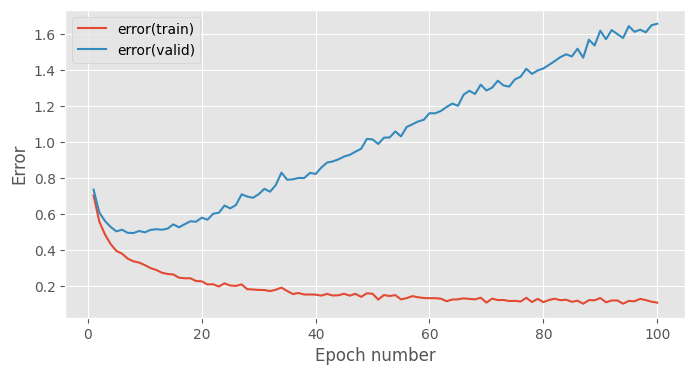

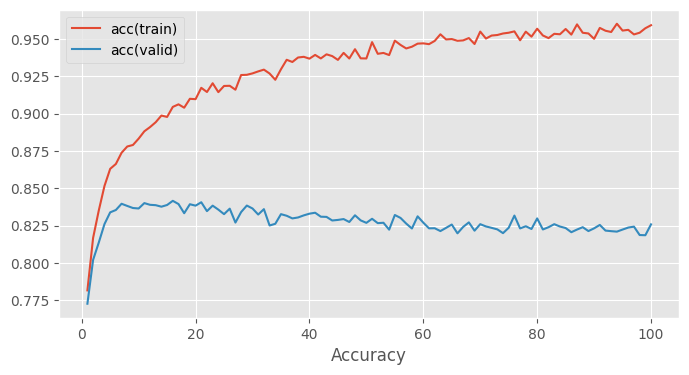

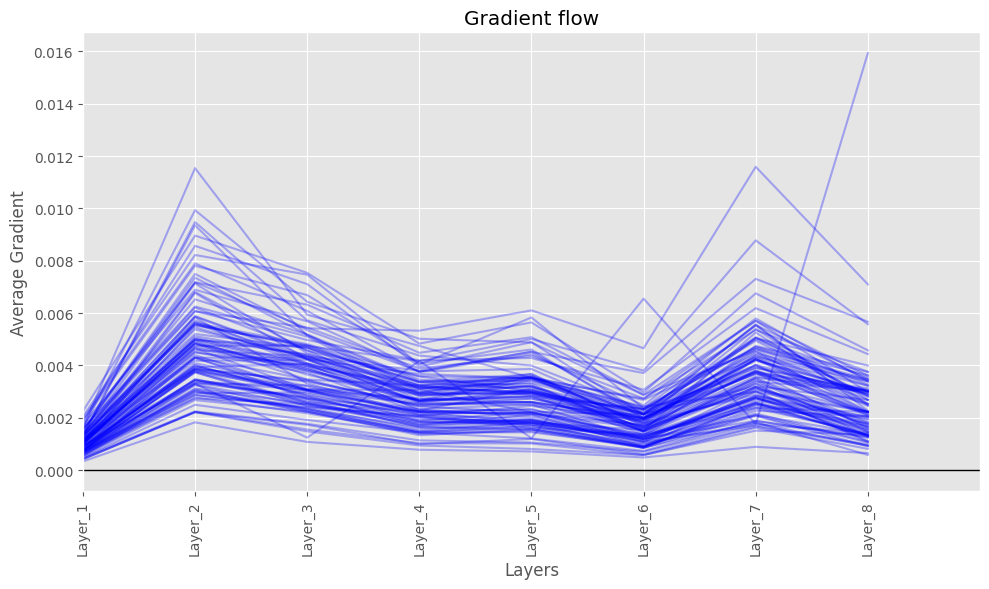

In [18]:
# --- Configuration for this specific run ---
num_hidden_layers = 3

# --- MODEL SETUP ---
print(f"\n--- Starting Experiment: {num_hidden_layers} Hidden Layer(s) ---")
weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# MODEL DEFINITION: 3 Hidden Layers
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # <--- Second Hidden Layer
    ReluLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init), # <--- Third Hidden Layer
    ReluLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init)
])

error = CrossEntropySoftmaxError()
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Run the training
stats_3, keys, run_time, *rest = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

# --- DATA EXTRACTION & SAVING ---
final_stats = stats_3[-1]
final_val_acc = final_stats[keys['acc(valid)']] * 100 
final_train_err = final_stats[keys['error(train)']]
final_val_err = final_stats[keys['error(valid)']]

# --- LOAD, APPEND, AND SAVE ---
with open(results_file_2, 'r') as f:
    results = json.load(f)

# Store results
results['data'].append([
    num_hidden_layers,
    f"{final_val_acc:.2f}",
    f"{final_train_err:.4f}",
    f"{final_val_err:.4f}"
])

with open(results_file_2, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n[SUCCESS] Depth {num_hidden_layers} Experiment completed.")
print(f"  Val Acc: {final_val_acc:.2f}%, Train Error: {final_train_err:.4f}, Val Error: {final_val_err:.4f}")
print("Data saved. Proceed to the next cell when ready.")

In [20]:
import json
# NOTE: This cell requires the definition of display_table(headers, data) from your earlier snippet.

# --- Function to print the table ---
def display_table(headers, data):
    # Function to format data cleanly
    data_str = [[str(r[0])] + r[1:] for r in data]
    
    # Check if data_str is empty before proceeding
    if not data_str:
        print("\n[INFO] No data available to display in the table. Run experiments first.")
        return
        
    col_widths = [max(len(h), max(len(d[i]) for d in data_str)) + 4
                  for i, h in enumerate(headers)]
    
    separator_line = "+" + "+".join(["-" * (w - 2) for w in col_widths]) + "+"
    total_width = len(separator_line)

    print("\n" + "="*total_width)
    print(f"| {'TABLE 2: VARYING NETWORK DEPTHS':^{total_width-2}} |")
    print("="*total_width)
    
    header_line = "|"
    for i, header in enumerate(headers):
        header_line += f" {header:^{col_widths[i]-2}} |"
    print(header_line)
    print(separator_line)

    for row in data_str:
        row_line = "|"
        for i, item in enumerate(row):
             row_line += f" {item:^{col_widths[i]-2}} |"
        print(row_line)

    print(separator_line)
    print("="*total_width + "\n")

# --- LOAD DATA AND DISPLAY ---
results_file_2 = 'table_2_results_depth.json'
try:
    with open(results_file_2, 'r') as f:
        results = json.load(f)
    
    # Sort the data by the number of hidden layers (first column)
    # The first element is converted to int for correct sorting (1, 2, 3)
    sortable_data = [[int(row[0])] + row[1:] for row in results['data']]
    sortable_data.sort(key=lambda x: x[0])
    
    display_table(results['headers'], sortable_data)
except FileNotFoundError:
    print(f"[ERROR] File '{results_file_2}' not found. Please run all training cells first.")
except Exception as e:
    print(f"[ERROR] Could not load or display results: {e}")


|               TABLE 2: VARYING NETWORK DEPTHS                |
|  # Hidden Layers  |  Val. Acc. (%)  |  Train Error  |  Val. Error  |
+-----------------+---------------+-------------+------------+
|         1         |      80.38      |    0.1600     |    0.9805    |
|         2         |      81.48      |    0.1143     |    1.5516    |
|         3         |      82.58      |    0.1070     |    1.6569    |
+-----------------+---------------+-------------+------------+



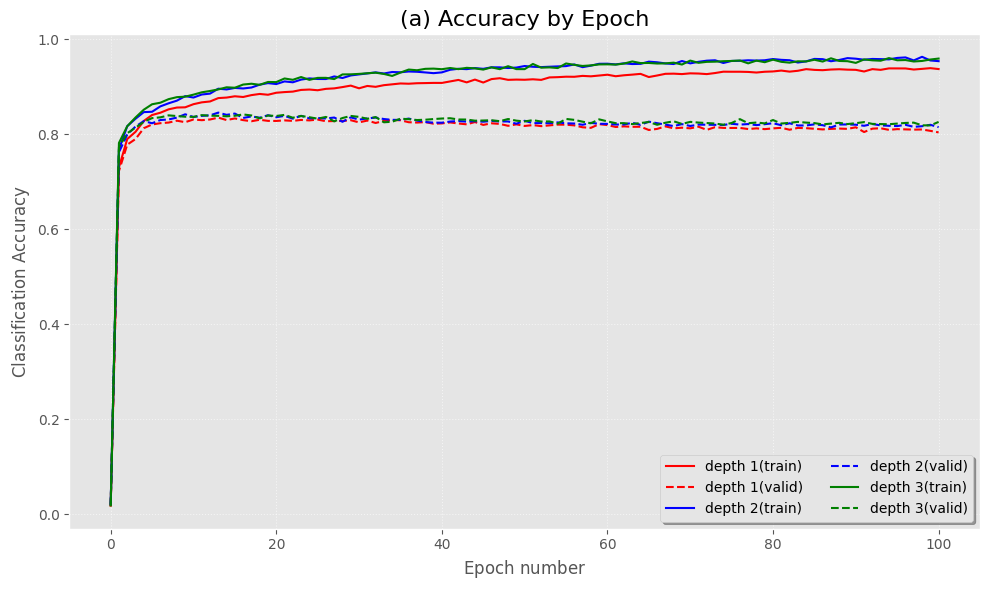

In [26]:
COLOR_MAP = {
    1: 'red',      # Depth 1
    2: 'blue',     # Depth 2
    3: 'green'     # Depth 3
}

try:
    all_stats = {
        'depth1': stats_1,
        'depth2': stats_2,
        'depth3': stats_3
    }
    epochs = np.arange(0, num_epochs + stats_interval, stats_interval)
    depths = [1, 2, 3]
except NameError as e:
    print(f"[ERROR] Variable missing: {e}.")
    raise

# Plot Generation for ACCURACY
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

all_handles = []
all_labels = []

for depth in depths:
    stats = all_stats[f'depth{depth}']
    color = COLOR_MAP[depth]
    
    train_acc = [s[keys['acc(train)']] for s in stats]
    valid_acc = [s[keys['acc(valid)']] for s in stats]
    
    # Plot Train (Solid)
    h_train, = ax.plot(epochs, train_acc, label=f'depth {depth}(train)', linestyle='-', color=color)
    # Plot Validation (Dashed)
    h_valid, = ax.plot(epochs, valid_acc, label=f'depth {depth}(valid)', linestyle='--', color=color)
    
    all_handles.extend([h_train, h_valid])
    all_labels.extend([f'depth {depth}(train)', f'depth {depth}(valid)'])

# Formatting
ax.set_title(r'(a) Accuracy by Epoch', fontsize=16)
ax.set_xlabel(r'$\mathrm{Epoch\ number}$', fontsize=12)
ax.set_ylabel(r'$\mathrm{Classification\ Accuracy}$', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)

ax.legend(all_handles, all_labels, 
          loc='lower right', 
          ncol=2, 
          fontsize=10,
          frameon=True, 
          fancybox=True, 
          shadow=True) 

fig.tight_layout() 
save_filename = 'emnist_depth_accuracy.png'
fig.savefig(save_filename, dpi=300) # dpi=300 for high resolution PNG
plt.show()

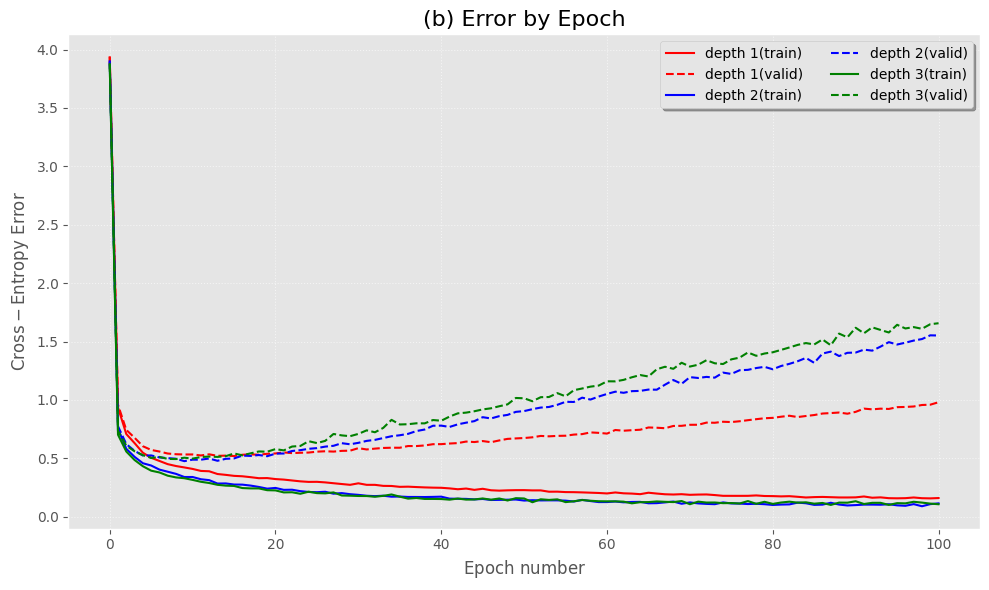

In [25]:
COLOR_MAP = {
    1: 'red',      
    2: 'blue',     
    3: 'green'     
}
try:
    all_stats = {
        'depth1': stats_1,
        'depth2': stats_2,
        'depth3': stats_3
    }
    epochs = np.arange(0, num_epochs + stats_interval, stats_interval)
    depths = [1, 2, 3]
except NameError as e:
    print(f"[ERROR] Variable missing: {e}.")
    raise

# Plot Generation for ERROR
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

all_handles = []
all_labels = []

for depth in depths:
    stats = all_stats[f'depth{depth}']
    color = COLOR_MAP[depth]
    
    train_error = [s[keys['error(train)']] for s in stats]
    valid_error = [s[keys['error(valid)']] for s in stats]
    
    # Plot Train (Solid)
    h_train, = ax.plot(epochs, train_error, label=f'depth {depth}(train)', linestyle='-', color=color)
    # Plot Validation (Dashed)
    h_valid, = ax.plot(epochs, valid_error, label=f'depth {depth}(valid)', linestyle='--', color=color)
    
    all_handles.extend([h_train, h_valid])
    all_labels.extend([f'depth {depth}(train)', f'depth {depth}(valid)'])

ax.set_title(r'(b) Error by Epoch', fontsize=16) 
ax.set_xlabel(r'$\mathrm{Epoch\ number}$', fontsize=12)
ax.set_ylabel(r'$\mathrm{Cross-Entropy\ Error}$', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)

ax.legend(all_handles, all_labels, 
          loc='upper right', 
          ncol=2, 
          fontsize=10,
          frameon=True, 
          fancybox=True, 
          shadow=True) 

fig.tight_layout()
save_filename = 'emnist_depth_error.png'
fig.savefig(save_filename, dpi=300) # dpi=300 for high resolution PNG
plt.show()

## Problematic Training

The following experiments show a failed training run. Run the code and investigate the reasons.

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: 10.2s to complete
    error(train)=3.85e+00, acc(train)=2.15e-02, error(valid)=3.85e+00, acc(valid)=2.07e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2: 9.4s to complete
    error(train)=3.85e+00, acc(train)=2.13e-02, error(valid)=3.85e+00, acc(valid)=2.20e-02


...

Epoch 3: 9.5s to complete
    error(train)=3.81e+00, acc(train)=4.26e-02, error(valid)=3.81e+00, acc(valid)=4.10e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 4: 9.2s to complete
    error(train)=3.52e+00, acc(train)=4.62e-02, error(valid)=3.52e+00, acc(valid)=4.99e-02


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 5: 9.2s to complete
    error(train)=3.39e+00, acc(train)=6.32e-02, error(valid)=3.40e+00, acc(valid)=6.85e-02


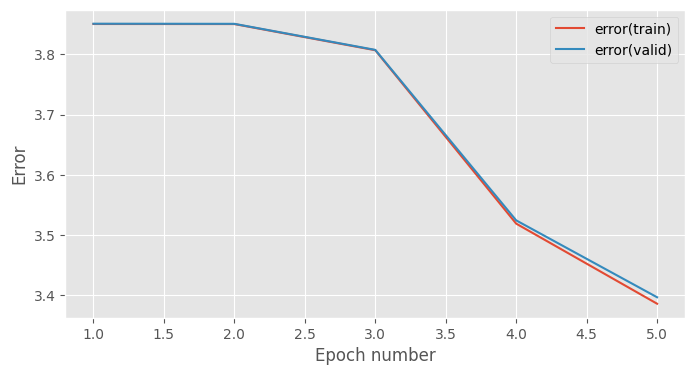

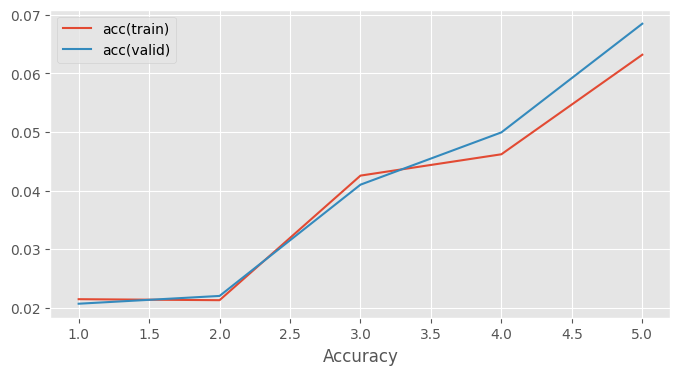

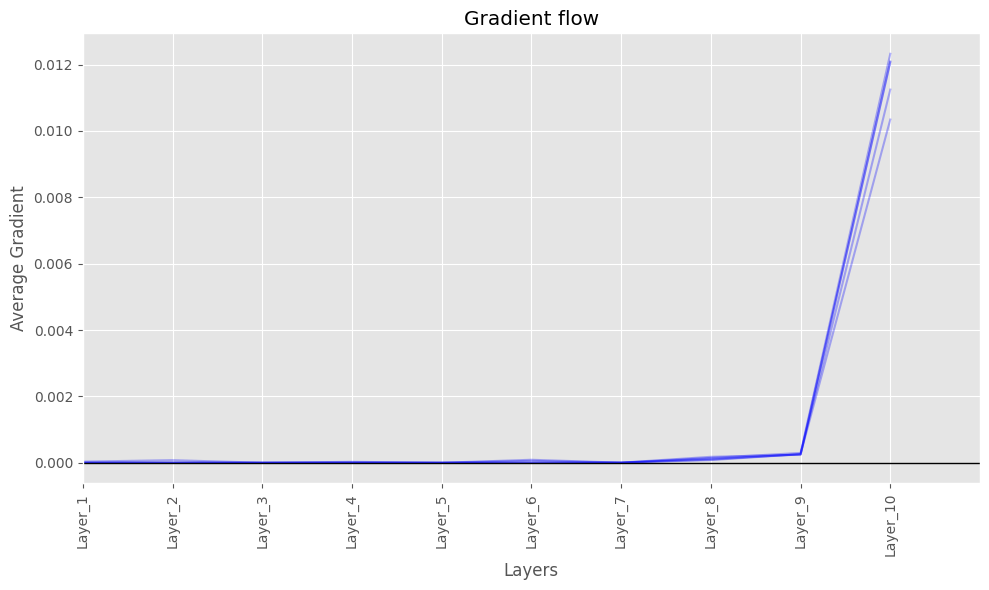

In [6]:
# Setup hyperparameters
learning_rate = 0.001
num_epochs = 5
stats_interval = 1
input_dim, output_dim, hidden_dim = 784, 47, 128

weights_init = GlorotUniformInit(rng=rng)
biases_init = ConstantInit(0.)

# Create model with four hidden layer
model = MultipleLayerModel([
    AffineLayer(input_dim, hidden_dim, weights_init, biases_init), 
    CustomActivationLayer(), 
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, hidden_dim, weights_init, biases_init),
    CustomActivationLayer(),
    AffineLayer(hidden_dim, output_dim, weights_init, biases_init) # output layer
])

error = CrossEntropySoftmaxError()
# Use a Adam learning rule
learning_rule = AdamLearningRule(learning_rate=learning_rate)

# Remember to use notebook=False when you write a script to be run in a terminal
stats, keys, run_time, fig_1, ax_1, fig_2, ax_2, grad_plot, grad_ax = train_model_and_plot_stats(
    model, error, learning_rule, train_data, valid_data, num_epochs, stats_interval, notebook=True)

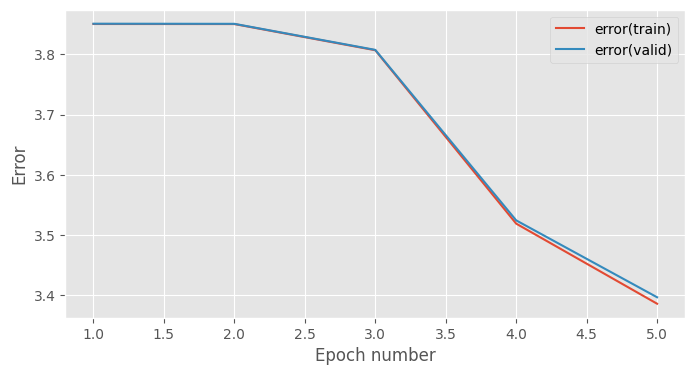

In [7]:
# You can then check the plots like this
fig_1 # The training error plot

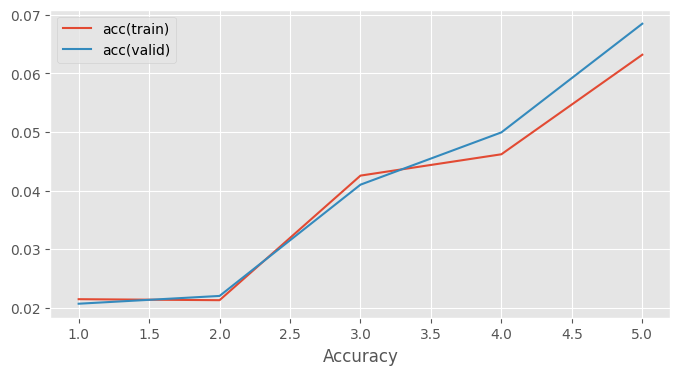

In [8]:
fig_2 # The training accuracy plot

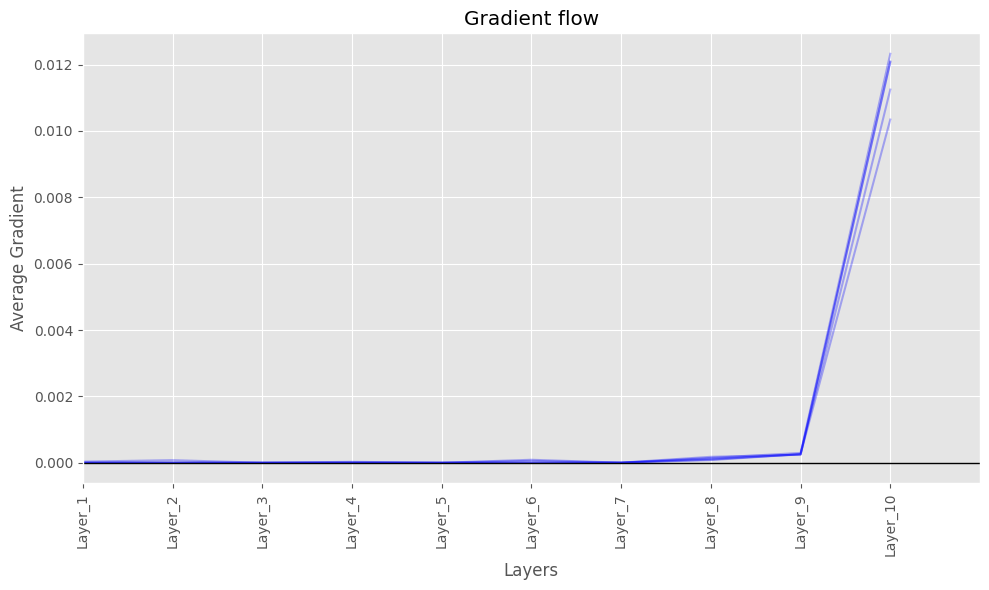

In [9]:
grad_plot # The gradient flow plot